# Notebook 13 — Punjab Top-Performer Verification

Bootstrap CI check, grade-level private sample audit, and school resource comparison for 11 Punjab districts and 1 KPK control district where government schools outperform private schools in arithmetic.

In [22]:
import os
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../outputs', exist_ok=True)
os.makedirs('../outputs/figures', exist_ok=True)

N_BOOT = 5000
SEED   = 42

# 11 Punjab districts + Haripur (KPK control)
TARGET_DISTRICTS = [
    'Faisalabad', 'Sahiwal', 'Sheikhupura', 'Okara', 'Lodhran',
    'Muzaffargarh', 'Multan', 'Sialkot', 'Chakwal', 'Dera Ghazi Khan',
    'Jhang', 'Haripur',
]

print(f'Verifying {len(TARGET_DISTRICTS)} districts.')

Verifying 12 districts.


## Step 1 — District summary stats

In [23]:
ds = pd.read_csv('../Data:/district_summary.csv')
ds_sub = (
    ds[ds['district'].isin(TARGET_DISTRICTS)]
    [['district', 'province', 'n_government', 'n_private',
      'govt_mean_arithmetic', 'pvt_mean_arithmetic', 'arithmetic_gap']]
    .copy()
    .sort_values('arithmetic_gap')
)

print('District-level summaries (sorted by gap, most negative first):')
print(ds_sub.to_string(index=False))
print()
print(f'All gaps negative: {(ds_sub["arithmetic_gap"] < 0).all()}')

District-level summaries (sorted by gap, most negative first):
       district province  n_government  n_private  govt_mean_arithmetic  pvt_mean_arithmetic  arithmetic_gap
     Faisalabad   Punjab           401        206                  5.28                 3.91           -1.37
        Sahiwal   Punjab           109         58                  5.46                 4.34           -1.12
    Sheikhupura   Punjab           163        196                  5.69                 4.61           -1.08
          Okara   Punjab           419        210                  5.11                 4.29           -0.82
        Lodhran   Punjab          1167        141                  5.72                 5.08           -0.64
        Haripur      KPK           373        264                  5.02                 4.43           -0.59
         Multan   Punjab           822        343                  5.69                 5.11           -0.58
   Muzaffargarh   Punjab           223         73                

## Step 2 — Grade-level private sample sizes

Flag any grade within a district where private-school sample size < 30 children. Thin samples at specific grades inflate or deflate the district mean.

In [24]:
df = pd.read_csv('../Data:/child_merged.csv',
                 usecols=['district', 'province', 'school_type', 'grade', 'arithmetic_score'])
df = df[df['school_type'].isin(['Government', 'Private'])].copy()

grade_rows = []
for dist in TARGET_DISTRICTS:
    sub = df[df['district'] == dist]
    pvt_by_grade = (
        sub[sub['school_type'] == 'Private']
        .groupby('grade').size()
        .reindex(range(1, 9), fill_value=0)   # grades 1-8 per spec
    )
    for grade, n in pvt_by_grade.items():
        grade_rows.append({'district': dist, 'grade': grade,
                           'pvt_n': n, 'flagged': n < 30})

grade_df = pd.DataFrame(grade_rows)
thin_summary = (
    grade_df.groupby('district')
    .agg(n_thin_grades=('flagged', 'sum'),
         min_pvt_n=('pvt_n', 'min'),
         grades_with_data=('pvt_n', lambda x: (x > 0).sum()))
    .reset_index()
)

print('Grades 1-8 private sample < 30 per district:')
print(thin_summary.to_string(index=False))
print()
print('Verdict: districts with thin private sample across most grades (n_thin >= 6):')
print(thin_summary[thin_summary['n_thin_grades'] >= 6]['district'].tolist())

Grades 1-8 private sample < 30 per district:
       district  n_thin_grades  min_pvt_n  grades_with_data
        Chakwal              8          4                 8
Dera Ghazi Khan              6         14                 8
     Faisalabad              4         12                 8
        Haripur              3         13                 8
          Jhang              1         16                 8
        Lodhran              7          1                 8
         Multan              2          5                 8
   Muzaffargarh              7          8                 8
          Okara              3         13                 8
        Sahiwal              8          5                 8
    Sheikhupura              5         14                 8
        Sialkot              0         34                 8

Verdict: districts with thin private sample across most grades (n_thin >= 6):
['Chakwal', 'Dera Ghazi Khan', 'Lodhran', 'Muzaffargarh', 'Sahiwal']


## Step 3 — Bootstrap CI on overall district gap

In [25]:
def bootstrap_gap_ci(govt_scores, pvt_scores, n_boot=N_BOOT, seed=SEED):
    rng   = np.random.default_rng(seed)
    g, p  = np.asarray(govt_scores, dtype=float), np.asarray(pvt_scores, dtype=float)
    idx_g = rng.integers(0, len(g), (n_boot, len(g)))
    idx_p = rng.integers(0, len(p), (n_boot, len(p)))
    gaps  = p[idx_p].mean(axis=1) - g[idx_g].mean(axis=1)
    return float(np.percentile(gaps, 2.5)), float(np.percentile(gaps, 97.5))

ci_rows = []
for dist in TARGET_DISTRICTS:
    sub  = df[(df['district'] == dist) & df['arithmetic_score'].notna()]
    gov  = sub[sub['school_type'] == 'Government']['arithmetic_score'].values
    pvt  = sub[sub['school_type'] == 'Private']['arithmetic_score'].values
    gap  = float(pvt.mean() - gov.mean())
    ci_l, ci_h = bootstrap_gap_ci(gov, pvt)
    pval = stats.ttest_ind(pvt, gov, equal_var=False).pvalue
    ci_rows.append({
        'district':        dist,
        'obs_gap':         round(gap,   3),
        'ci_low':          round(ci_l,  3),
        'ci_high':         round(ci_h,  3),
        'ci_below_zero':   ci_h < 0,
        'welch_p':         round(pval,  4),
    })

ci_df = pd.DataFrame(ci_rows)
print('95% bootstrap CIs on district gap (all < 0 means govt robustly better):')
print(ci_df.to_string(index=False))
print()
print(f'Districts where CI is entirely below zero: {ci_df["ci_below_zero"].sum()} of {len(ci_df)}')

95% bootstrap CIs on district gap (all < 0 means govt robustly better):
       district  obs_gap  ci_low  ci_high  ci_below_zero  welch_p
     Faisalabad   -1.469  -1.779   -1.149           True   0.0000
        Sahiwal   -0.934  -1.599   -0.248           True   0.0061
    Sheikhupura   -1.191  -1.506   -0.853           True   0.0000
          Okara   -0.750  -1.059   -0.448           True   0.0000
        Lodhran   -0.919  -1.236   -0.595           True   0.0000
   Muzaffargarh   -0.467  -0.900   -0.031           True   0.0400
         Multan   -0.915  -1.147   -0.690           True   0.0000
        Sialkot   -0.542  -0.770   -0.308           True   0.0000
        Chakwal   -0.600  -1.132   -0.060           True   0.0306
Dera Ghazi Khan   -0.750  -1.131   -0.387           True   0.0001
          Jhang   -0.328  -0.574   -0.101           True   0.0069
        Haripur   -0.737  -1.005   -0.453           True   0.0000

Districts where CI is entirely below zero: 12 of 12


## Step 4 — School-resource operational metrics

For each district's government schools, compute median pupil-teacher ratio, teacher attendance rate, student attendance rate, and share with class-2 textbooks. Compare to national government-school averages.

In [26]:
sr        = pd.read_csv('../Data:/school_resources.csv')
nat_govt  = sr[sr['school_type'] == 'Government']

NAT_REF = {
    'pupil_teacher_ratio':     round(float(nat_govt['pupil_teacher_ratio'].median()),     1),
    'teacher_attendance_rate': round(float(nat_govt['teacher_attendance_rate'].median()), 1),
    'attendance_rate':         round(float(nat_govt['attendance_rate'].median()),         1),
    'class2_has_textbooks':    round(float(nat_govt['class2_has_textbooks'].mean()),      3),
}
print('National government-school reference values (median PTR, median rates, mean textbooks):')
for k, v in NAT_REF.items():
    print(f'  {k}: {v}')
print()

res_rows = []
for dist in TARGET_DISTRICTS:
    g   = nat_govt[nat_govt['district'] == dist]
    ptr = round(float(g['pupil_teacher_ratio'].median()),     1)
    ta  = round(float(g['teacher_attendance_rate'].median()), 1)
    att = round(float(g['attendance_rate'].median()),         1)
    tb  = round(float(g['class2_has_textbooks'].mean()),      3)
    res_rows.append({
        'district':          dist,
        'n_govt_schools':    len(g),
        'median_PTR':        ptr,
        'median_teacher_att': ta,
        'median_student_att': att,
        'mean_textbooks':    tb,
        'PTR_ok':            ptr <= NAT_REF['pupil_teacher_ratio'],
        'teacher_att_ok':    ta  >= NAT_REF['teacher_attendance_rate'],
        'student_att_ok':    att >= NAT_REF['attendance_rate'],
        'textbooks_ok':      tb  >= NAT_REF['class2_has_textbooks'],
    })

res_df = pd.DataFrame(res_rows)
res_df['metrics_above_nat'] = (
    res_df[['PTR_ok', 'teacher_att_ok', 'student_att_ok', 'textbooks_ok']]
    .sum(axis=1)
)
print('Per-district government school metrics (reference values shown in parentheses):')
print(f'  PTR ref  = {NAT_REF["pupil_teacher_ratio"]}  (lower is better)')
print(f'  Teacher att ref = {NAT_REF["teacher_attendance_rate"]}%')
print(f'  Student att ref = {NAT_REF["attendance_rate"]}%')
print(f'  Textbooks ref   = {NAT_REF["class2_has_textbooks"]}')
print()
print(res_df[['district','median_PTR','median_teacher_att','median_student_att',
              'mean_textbooks','metrics_above_nat']].to_string(index=False))

National government-school reference values (median PTR, median rates, mean textbooks):
  pupil_teacher_ratio: 24.8
  teacher_attendance_rate: 83.3
  attendance_rate: 89.6
  class2_has_textbooks: 0.179

Per-district government school metrics (reference values shown in parentheses):
  PTR ref  = 24.8  (lower is better)
  Teacher att ref = 83.3%
  Student att ref = 89.6%
  Textbooks ref   = 0.179

       district  median_PTR  median_teacher_att  median_student_att  mean_textbooks  metrics_above_nat
     Faisalabad        32.0                83.8                92.2           0.433                  3
        Sahiwal        21.8                91.7               100.0           0.267                  4
    Sheikhupura        26.7                81.7                94.8           0.367                  2
          Okara        28.0                13.3                90.3           0.433                  2
        Lodhran        30.6               100.0                98.0           0.700   

## Combined output table

In [27]:
combined = (
    ds_sub
    .merge(thin_summary[['district', 'n_thin_grades', 'min_pvt_n']], on='district')
    .merge(ci_df,                                                     on='district')
    .merge(res_df[['district','n_govt_schools','median_PTR','median_teacher_att',
                   'median_student_att','mean_textbooks','metrics_above_nat']], on='district')
    .sort_values('arithmetic_gap')
)

print('Combined verification table:')
print(combined.to_string(index=False))

combined.to_csv('../outputs/punjab_top_performers_verified.csv', index=False)
print('\nSaved outputs/punjab_top_performers_verified.csv')

Combined verification table:
       district province  n_government  n_private  govt_mean_arithmetic  pvt_mean_arithmetic  arithmetic_gap  n_thin_grades  min_pvt_n  obs_gap  ci_low  ci_high  ci_below_zero  welch_p  n_govt_schools  median_PTR  median_teacher_att  median_student_att  mean_textbooks  metrics_above_nat
     Faisalabad   Punjab           401        206                  5.28                 3.91           -1.37              4         12   -1.469  -1.779   -1.149           True   0.0000              30        32.0                83.8                92.2           0.433                  3
        Sahiwal   Punjab           109         58                  5.46                 4.34           -1.12              8          5   -0.934  -1.599   -0.248           True   0.0061              30        21.8                91.7               100.0           0.267                  4
    Sheikhupura   Punjab           163        196                  5.69                 4.61           -1.0

## Visual: Gap CI with resource-quality indicator

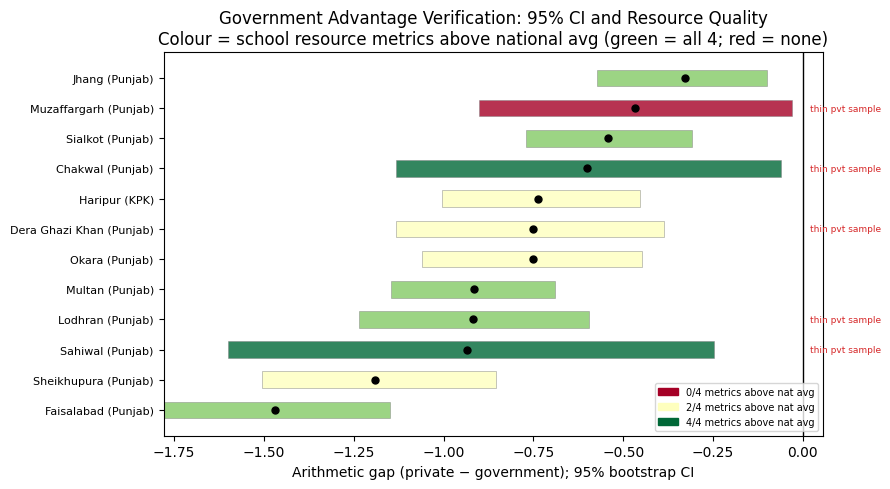

Saved 13a_punjab_ci_verification.


In [28]:
plot_df = combined.sort_values('obs_gap')

# Colour by number of metrics above national average
cmap   = plt.cm.RdYlGn
colours = [cmap(m / 4.0) for m in plot_df['metrics_above_nat']]

fig, ax = plt.subplots(figsize=(9, 5))

y_pos = np.arange(len(plot_df))
ax.barh(y_pos, plot_df['ci_high'] - plot_df['ci_low'],
        left=plot_df['ci_low'], height=0.55,
        color=colours, alpha=0.8, edgecolor='grey', linewidth=0.4, zorder=2)
ax.scatter(plot_df['obs_gap'], y_pos, color='black', s=25, zorder=3)

ax.axvline(0, color='black', lw=1.0, zorder=4)

# Thin-sample warning markers
for i, (_, row) in enumerate(plot_df.iterrows()):
    if row['n_thin_grades'] >= 6:
        ax.text(plot_df['ci_high'].max() + 0.05, i, 'thin pvt sample',
                va='center', fontsize=6.5, color='#d62728')

ax.set_yticks(y_pos)
ax.set_yticklabels(
    [f"{r['district']} ({r['province']})" for _, r in plot_df.iterrows()],
    fontsize=8
)
ax.set_xlabel('Arithmetic gap (private − government); 95% bootstrap CI')
ax.set_title('Government Advantage Verification: 95% CI and Resource Quality\n'
             'Colour = school resource metrics above national avg (green = all 4; red = none)')

# Colour legend
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=cmap(0/4), label='0/4 metrics above nat avg'),
    mpatches.Patch(color=cmap(2/4), label='2/4 metrics above nat avg'),
    mpatches.Patch(color=cmap(4/4), label='4/4 metrics above nat avg'),
]
ax.legend(handles=legend_patches, fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig('../outputs/figures/13a_punjab_ci_verification.png', dpi=150, bbox_inches='tight')
plt.savefig('../outputs/figures/13a_punjab_ci_verification.pdf', bbox_inches='tight')
plt.show()
print('Saved 13a_punjab_ci_verification.')